# Connect-4 Supervised Pretraining (CNet192) — with checkpoint continuation

**Input encoding (1 channel, POV):**
- empty = 0
- current player = +1
- opponent = -1

This version can start from scratch, continue from a supervised CNet192 checkpoint, continue from a compatible PPO checkpoint, or resume a full training-state checkpoint.


In [1]:
# Imports & config
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.optim.lr_scheduler import LambdaLR, ReduceLROnPlateau
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from C4.CNet192 import CNet192, save_cnet192, load_cnet192
from zipfile import BadZipFile
from tqdm.auto import tqdm
import random

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ---- Paths ----
DATA_FILES = [
    # initial
    "DATA/C4.train_data_random.xlsx",
    "DATA/C4.train_data_basic.xlsx",
    "DATA/C4.train_data_basic_LA3+.xlsx",
    "DATA/C4.train_data_basic_LA5+.xlsx",
    "DATA/C4.train_data_basic_LA7+.xlsx",
    "DATA/C4.train_data_odd.xlsx",
    "DATA/C4.train_data_LA13+.xlsx",
    "DATA/C4.train_data_sweep.xlsx",
    "DATA/C4.train_data_ultra.xlsx",
    "DATA/C4.train_data_center_and_left.xlsx",
    "DATA/C4.train_data_openings.xlsx",
    "DATA/C4.train_data_L1_L3.xlsx",
    
    # from PPO models
    "DATA/C4.train_data_ppo_PPO_403.xlsx",
    "DATA/C4.train_data_ppo_PPO_430.xlsx",
    "DATA/C4.train_data_ppo_PPO_413.xlsx",

    "DATA/C4.train_data_ppo_PPO_507.xlsx",

    "DATA/C4.train_data_ppo_PPO_601.xlsx",
    "DATA/C4.train_data_ppo_PPO_602.xlsx",
    "DATA/C4.train_data_ppo_PPO_603.xlsx",
    "DATA/C4.train_data_ppo_PPO_604.xlsx",
    "DATA/C4.train_data_ppo_PPO_605.xlsx",
    "DATA/C4.train_data_ppo_PPO_606.xlsx",

    "DATA/C4.train_data_ppo_PPO_6001.xlsx",
    "DATA/C4.train_data_ppo_PPO_6002.xlsx",
    "DATA/C4.train_data_ppo_PPO_6003.xlsx",
    "DATA/C4.train_data_ppo_PPO_6004.xlsx",
    "DATA/C4.train_data_ppo_PPO_6006.xlsx",
    "DATA/C4.train_data_ppo_PPO_6009.xlsx",
    "DATA/C4.train_data_ppo_PPO_6010.xlsx",
    "DATA/C4.train_data_ppo_PPO_6011.xlsx",
    
    "DATA/C4.train_data_ppo_PPO_6101.xlsx",
    "DATA/C4.train_data_ppo_PPO_6102.xlsx",
    "DATA/C4.train_data_ppo_PPO_6103.xlsx",
    "DATA/C4.train_data_ppo_PPO_6104.xlsx",
    "DATA/C4.train_data_ppo_PPO_6105.xlsx",
    "DATA/C4.train_data_ppo_PPO_6106.xlsx",
    "DATA/C4.train_data_ppo_PPO_6107.xlsx",
    "DATA/C4.train_data_ppo_PPO_6108.xlsx",
    "DATA/C4.train_data_ppo_PPO_6109.xlsx",
    "DATA/C4.train_data_ppo_PPO_6110.xlsx",
    "DATA/C4.train_data_ppo_PPO_6111.xlsx",
    "DATA/C4.train_data_ppo_PPO_6112.xlsx",
    "DATA/C4.train_data_ppo_PPO_6113.xlsx",
    "DATA/C4.train_data_ppo_PPO_6114.xlsx",

    "DATA/C4.train_data_ppo_PPO_701.xlsx",
    "DATA/C4.train_data_ppo_PPO_702GS.xlsx",
    "DATA/C4.train_data_ppo_PPO_703.xlsx",
    "DATA/C4.train_data_ppo_PPO_704.xlsx",
    "DATA/C4.train_data_ppo_PPO_705.xlsx",
    "DATA/C4.train_data_ppo_PPO_706.xlsx",
    "DATA/C4.train_data_ppo_PPO_707.xlsx",
    "DATA/C4.train_data_ppo_PPO_708.xlsx",
    "DATA/C4.train_data_ppo_PPO_709.xlsx",
    "DATA/C4.train_data_ppo_PPO_710.xlsx",
    "DATA/C4.train_data_ppo_PPO_711.xlsx",
    "DATA/C4.train_data_ppo_PPO_712.xlsx",
    "DATA/C4.train_data_ppo_PPO_713.xlsx",
    "DATA/C4.train_data_ppo_PPO_714.xlsx",
    "DATA/C4.train_data_ppo_PPO_715.xlsx",
    "DATA/C4.train_data_ppo_PPO_716.xlsx",
    "DATA/C4.train_data_ppo_PPO_717.xlsx",
    "DATA/C4.train_data_ppo_PPO_718.xlsx",
    "DATA/C4.train_data_ppo_PPO_719.xlsx",
    "DATA/C4.train_data_ppo_PPO_720.xlsx",
    "DATA/C4.train_data_ppo_PPO_721.xlsx",
    "DATA/C4.train_data_ppo_PPO_722.xlsx",
    "DATA/C4.train_data_ppo_PPO_723.xlsx",
    "DATA/C4.train_data_ppo_PPO_724.xlsx",
    "DATA/C4.train_data_ppo_PPO_725.xlsx",
    "DATA/C4.train_data_ppo_PPO_726.xlsx",
    "DATA/C4.train_data_ppo_PPO_727.xlsx",
    "DATA/C4.train_data_ppo_PPO_728.xlsx",
    "DATA/C4.train_data_ppo_PPO_729.xlsx",
    "DATA/C4.train_data_ppo_PPO_730.xlsx",
    "DATA/C4.train_data_ppo_PPO_731.xlsx",
    "DATA/C4.train_data_ppo_PPO_732.xlsx",
    "DATA/C4.train_data_ppo_PPO_733.xlsx",
    "DATA/C4.train_data_ppo_PPO_735.xlsx",
    "DATA/C4.train_data_ppo_PPO_736.xlsx",
    "DATA/C4.train_data_ppo_PPO_737.xlsx",
    "DATA/C4.train_data_ppo_PPO_739.xlsx",
    "DATA/C4.train_data_ppo_PPO_742.xlsx",
    "DATA/C4.train_data_ppo_PPO_743.xlsx",
    "DATA/C4.train_data_ppo_PPO_744.xlsx",
    "DATA/C4.train_data_ppo_PPO_745.xlsx",
    "DATA/C4.train_data_ppo_PPO_746.xlsx",
    "DATA/C4.train_data_ppo_PPO_747.xlsx",
    "DATA/C4.train_data_ppo_PPO_748.xlsx",
    "DATA/C4.train_data_ppo_PPO_749.xlsx",
    "DATA/C4.train_data_ppo_PPO_750.xlsx",
    "DATA/C4.train_data_ppo_PPO_751.xlsx",
    "DATA/C4.train_data_ppo_PPO_752.xlsx",
    "DATA/C4.train_data_ppo_PPO_753.xlsx",
    "DATA/C4.train_data_ppo_PPO_754.xlsx",
    "DATA/C4.train_data_ppo_PPO_755.xlsx",
    "DATA/C4.train_data_ppo_PPO_756.xlsx",
    "DATA/C4.train_data_ppo_PPO_757.xlsx",
    "DATA/C4.train_data_ppo_PPO_758.xlsx",
    "DATA/C4.train_data_ppo_PPO_759.xlsx",
    "DATA/C4.train_data_ppo_PPO_760.xlsx",
    "DATA/C4.train_data_ppo_PPO_761.xlsx",
    "DATA/C4.train_data_ppo_PPO_762.xlsx",
    "DATA/C4.train_data_ppo_PPO_763.xlsx",
    "DATA/C4.train_data_ppo_PPO_764.xlsx",
    "DATA/C4.train_data_ppo_PPO_765.xlsx",
    "DATA/C4.train_data_ppo_PPO_766.xlsx",

    "DATA/C4.train_data_ppo_PPO_801.xlsx",
    "DATA/C4.train_data_ppo_PPO_802.xlsx",
    "DATA/C4.train_data_ppo_PPO_803.xlsx",
    "DATA/C4.train_data_ppo_PPO_804.xlsx",
    "DATA/C4.train_data_ppo_PPO_805.xlsx",
    "DATA/C4.train_data_ppo_PPO_806.xlsx",
    "DATA/C4.train_data_ppo_PPO_807.xlsx",
    "DATA/C4.train_data_ppo_PPO_808.xlsx",
    "DATA/C4.train_data_ppo_PPO_809.xlsx",
    "DATA/C4.train_data_ppo_PPO_810.xlsx",
    "DATA/C4.train_data_ppo_PPO_811.xlsx",
    "DATA/C4.train_data_ppo_PPO_812.xlsx",
    "DATA/C4.train_data_ppo_PPO_813.xlsx",
    "DATA/C4.train_data_ppo_PPO_814.xlsx",
    "DATA/C4.train_data_ppo_PPO_815.xlsx",
    "DATA/C4.train_data_ppo_PPO_816.xlsx",
    "DATA/C4.train_data_ppo_PPO_817.xlsx",
    "DATA/C4.train_data_ppo_PPO_818.xlsx",
    "DATA/C4.train_data_ppo_PPO_819.xlsx",
    "DATA/C4.train_data_ppo_PPO_820.xlsx",
    "DATA/C4.train_data_ppo_PPO_821.xlsx",
    "DATA/C4.train_data_ppo_PPO_822.xlsx",
    "DATA/C4.train_data_ppo_PPO_823.xlsx",
    "DATA/C4.train_data_ppo_PPO_824.xlsx",
    "DATA/C4.train_data_ppo_PPO_825.xlsx",
    "DATA/C4.train_data_ppo_PPO_826.xlsx",
    "DATA/C4.train_data_ppo_PPO_827.xlsx",
    "DATA/C4.train_data_ppo_PPO_828.xlsx",
    "DATA/C4.train_data_ppo_PPO_829.xlsx",
    "DATA/C4.train_data_ppo_PPO_830.xlsx",
    "DATA/C4.train_data_ppo_PPO_831.xlsx",
    "DATA/C4.train_data_ppo_PPO_832.xlsx",
    "DATA/C4.train_data_ppo_PPO_834.xlsx",
    "DATA/C4.train_data_ppo_PPO_835.xlsx",
    "DATA/C4.train_data_ppo_PPO_836.xlsx",
    "DATA/C4.train_data_ppo_PPO_837.xlsx",
    "DATA/C4.train_data_ppo_PPO_838.xlsx",
    "DATA/C4.train_data_ppo_PPO_839.xlsx",
    "DATA/C4.train_data_ppo_PPO_840.xlsx",
    "DATA/C4.train_data_ppo_PPO_841.xlsx",
    "DATA/C4.train_data_ppo_PPO_842.xlsx",
    "DATA/C4.train_data_ppo_PPO_843.xlsx",
    "DATA/C4.train_data_ppo_PPO_844.xlsx",
    "DATA/C4.train_data_ppo_PPO_845.xlsx",
    "DATA/C4.train_data_ppo_PPO_846.xlsx",
    "DATA/C4.train_data_ppo_PPO_847.xlsx",
    "DATA/C4.train_data_ppo_PPO_848.xlsx",
    "DATA/C4.train_data_ppo_PPO_849.xlsx",
    "DATA/C4.train_data_ppo_PPO_850.xlsx",
    "DATA/C4.train_data_ppo_PPO_851.xlsx",
    "DATA/C4.train_data_ppo_PPO_852X.xlsx",
    "DATA/C4.train_data_ppo_PPO_853.xlsx",
    "DATA/C4.train_data_ppo_PPO_854.xlsx",
    "DATA/C4.train_data_ppo_PPO_855.xlsx",
    "DATA/C4.train_data_ppo_PPO_856.xlsx",
    "DATA/C4.train_data_ppo_PPO_857.xlsx",
    "DATA/C4.train_data_ppo_PPO_858.xlsx",
    "DATA/C4.train_data_ppo_PPO_859.xlsx",

    "DATA/C4.train_data_ppo_PPO_901.xlsx",
    "DATA/C4.train_data_ppo_PPO_902.xlsx",
    "DATA/C4.train_data_ppo_PPO_903.xlsx",
    "DATA/C4.train_data_ppo_PPO_904.xlsx",
    "DATA/C4.train_data_ppo_PPO_905.xlsx",
    "DATA/C4.train_data_ppo_PPO_906.xlsx",
    "DATA/C4.train_data_ppo_PPO_907.xlsx",
    "DATA/C4.train_data_ppo_PPO_908.xlsx",
    "DATA/C4.train_data_ppo_PPO_909.xlsx",
    "DATA/C4.train_data_ppo_PPO_910.xlsx",
    "DATA/C4.train_data_ppo_PPO_911.xlsx",
    "DATA/C4.train_data_ppo_PPO_912.xlsx",
    "DATA/C4.train_data_ppo_PPO_913.xlsx",
    "DATA/C4.train_data_ppo_PPO_914.xlsx",
    "DATA/C4.train_data_ppo_PPO_915.xlsx",
    "DATA/C4.train_data_ppo_PPO_916.xlsx",
    "DATA/C4.train_data_ppo_PPO_917.xlsx",
    "DATA/C4.train_data_ppo_PPO_918.xlsx",
    "DATA/C4.train_data_ppo_PPO_919.xlsx",
    "DATA/C4.train_data_ppo_PPO_920.xlsx",
    "DATA/C4.train_data_ppo_PPO_921.xlsx",
    "DATA/C4.train_data_ppo_PPO_922.xlsx",
    "DATA/C4.train_data_ppo_PPO_923.xlsx",
    "DATA/C4.train_data_ppo_PPO_924.xlsx",
    
    # depth based
    "DATA/C4.train_data_depth_based_LA.xlsx",
    "DATA/C4.train_data_depth_based_RCL.xlsx",
    "DATA/C4.train_data_depth_based_openings.xlsx",
    "DATA/C4.train_data_depth_based_expert.xlsx",
    "DATA/C4.train_data_depth_based_main.xlsx",
    "DATA/C4.train_data_depth_based_ultra_odd.xlsx",

    #non random start
    "DATA/C4.train_data_base_nornd.xlsx",

    #deeponly
    "DATA/C4.train_data_deep_vs_shallow.xlsx",
    "DATA/C4.train_data_deep_vs_noisy_shallow.xlsx",
    "DATA/C4.train_data_masterclass.xlsx",
    "DATA/C4.train_data_ultra_15.xlsx",

    #odd teacher focus
    "DATA/C4.train_data_deep_odd_vs_shallow.xlsx",
    "DATA/C4.train_data_shallow_teacher.xlsx",
    "DATA/C4.train_data_teacher_vs_noisy_shallow.xlsx",
    "DATA/C4.train_data_noisy_shallow_vs_teacher.xlsx",
    "DATA/C4.train_data_even_teacher.xlsx",
    "DATA/C4.train_data_odd_teacher.xlsx",
    "DATA/C4.train_data_ultra_15-17.xlsx",

    # drills
    "DATA/C4.train_data_drill_L1.xlsx",
    "DATA/C4.train_data_drill_L2.xlsx",
    "DATA/C4.train_data_drill_L3.xlsx",
    "DATA/C4.train_data_drill_L4.xlsx",
    "DATA/C4.train_data_drill_L5.xlsx",
    "DATA/C4.train_data_drill_L6.xlsx",

    # bit bully opening book
    "DATA/BitBully_12ply_rows_part000001.xlsx",
    "DATA/BitBully_12ply_rows_part000002.xlsx",
    "DATA/BitBully_12ply_rows_part000003.xlsx",
    "DATA/BitBully_12ply_rows_part000004.xlsx",
    "DATA/BitBully_12ply_rows_part000005.xlsx",
    "DATA/BitBully_12ply_rows_part000006.xlsx",
    "DATA/BitBully_12ply_rows_part000007.xlsx",
    "DATA/BitBully_12ply_rows_part000008.xlsx",
    "DATA/BitBully_12ply_rows_part000009.xlsx",
    "DATA/BitBully_12ply_rows_part000010.xlsx",
    "DATA/BitBully_12ply_rows_part000011.xlsx",
    "DATA/BitBully_12ply_rows_part000012.xlsx",
    "DATA/BitBully_12ply_rows_part000013.xlsx",
    "DATA/BitBully_12ply_rows_part000014.xlsx",
    "DATA/BitBully_12ply_rows_part000015.xlsx",
    "DATA/BitBully_12ply_rows_part000016.xlsx",
    "DATA/BitBully_12ply_rows_part000017.xlsx",
    "DATA/BitBully_12ply_rows_part000018.xlsx",
    "DATA/BitBully_12ply_rows_part000019.xlsx",
    "DATA/BitBully_12ply_rows_part000020.xlsx",
    "DATA/BitBully_12ply_rows_part000021.xlsx",
    "DATA/BitBully_12ply_rows_part000022.xlsx",
    "DATA/BitBully_12ply_rows_part000023.xlsx",
    "DATA/BitBully_12ply_rows_part000024.xlsx",
    "DATA/BitBully_12ply_rows_part000025.xlsx",
    "DATA/BitBully_12ply_rows_part000026.xlsx",
    "DATA/BitBully_12ply_rows_part000027.xlsx",
    "DATA/BitBully_12ply_rows_part000028.xlsx",
    "DATA/BitBully_12ply_rows_part000029.xlsx",
    "DATA/BitBully_12ply_rows_part000030.xlsx",
    "DATA/BitBully_12ply_rows_part000031.xlsx",
    "DATA/BitBully_12ply_rows_part000032.xlsx",
    "DATA/BitBully_12ply_rows_part000033.xlsx",
    "DATA/BitBully_12ply_rows_part000034.xlsx",

    #UCI 8-play states
    "DATA/UCI_connect4_L7.xlsx",
    "DATA/UCI_connect4_L8.xlsx",
    "DATA/UCI_connect4_L9.xlsx",
    "DATA/UCI_connect4_L10.xlsx",
    "DATA/UCI_connect4_L11.xlsx",
    "DATA/UCI_connect4_L12.xlsx",
    "DATA/UCI_connect4_L13.xlsx",

    #playing second focus
    "DATA/C4.playing_second.xlsx",

    # even training
    "DATA/C4.evil_evens_10.xlsx",
    "DATA/C4.evil_evens_12.xlsx",
]

OUT_DIR = Path("./out_supervised")
OUT_DIR.mkdir(parents=True, exist_ok=True)


DEVICE: cuda


In [2]:
# # ---- Training knobs ----
# BATCH_SIZE = 256        #128
# EPOCHS = 60 
# LR = 1.05e-3            #1.1e-3
# WEIGHT_DECAY = 1e-3     #1e-3
# VAL_FRAC = 0.04
# TEST_FRAC = 0.02
# USE_SOFT_LABELS = True

# SOFT_TEMP = 1.01          # 1.25; >1 softer (usually better val), <1 sharper (often better hard acc)
# SOFT_SMOOTH = 0.005       # mix teacher probs with uniform a bit to reduce overconfidence
# HARD_SOFT_ALPHA = 0.95    # 0.85; 1.0 = only soft CE, 0.0 = only hard CE
# GRAD_CLIP_NORM = 1.0      # set 0 to disable
# GRAD_ACCUM_STEPS = 1      # e.g. 4 => effective batch 256 with BATCH_SIZE=64
# SCHED = "cosine"          # "cosine" | "plateau" | None
# MIN_LR = 2e-5
# WARMUP_EPOCHS = 2

# EARLYSTOP_PATIENCE = 10   # stop if no meaningful val_inbest improvement
# EARLYSTOP_MIN_DELTA = 2e-4

# SEED = 666
# torch.manual_seed(SEED)
# np.random.seed(SEED)

In [3]:
# ---- Training knobs ---- gen11 / continuation-ready
BATCH_SIZE = 256
EPOCHS = 10                  # number of epochs to run THIS session

LR = 8.0e-4
WEIGHT_DECAY = 1.6e-3

VAL_FRAC = 0.04
TEST_FRAC = 0.02
USE_SOFT_LABELS = True

SOFT_TEMP = 1.06              # keep close to Gen10; Base10 was strong
SOFT_SMOOTH = 0.010
HARD_SOFT_ALPHA = 0.95

GRAD_CLIP_NORM = 1.0          # set 0 to disable
GRAD_ACCUM_STEPS = 1

SCHED = "cosine"              # "cosine" | "plateau" | None
MIN_LR = 1.5e-5
WARMUP_EPOCHS = 3

EARLYSTOP_PATIENCE = 15
EARLYSTOP_MIN_DELTA = 5e-5

# -----------------------------------------------------------------------------
# Checkpoint-start mode
# -----------------------------------------------------------------------------
# INIT_MODE:
#   "scratch" -> initialize a fresh CNet192
#   "weights" -> load model weights only, then start a fresh optimizer/scheduler
#   "full"    -> load model + optimizer/scheduler/history from a training-state checkpoint
#
# For adding more supervised epochs to BASE_10:
#   INIT_MODE = "weights"
#   INIT_CHECKPOINT = "SupervisedModels/BASE_10.pt"
#
# For supervised continuation from a compatible PPO:
#   INIT_MODE = "weights"
#   INIT_CHECKPOINT = "PPO_Models/PPO_921.pt"
#
# For exact notebook resume after interruption:
#   INIT_MODE = "full"
#   INIT_CHECKPOINT = OUT_DIR / "GEN11_FROM_BASE10_last_train_state.pt"
# -----------------------------------------------------------------------------

INIT_MODE = "weights"         # "scratch" | "weights" | "full"
INIT_CHECKPOINT = "PPO_Models/PPO_1004.pt"          # e.g. "SupervisedModels/BASE_10.pt" or "PPO_Models/PPO_921.pt"

# If loading weights only, this is just for nicer epoch numbering in logs/snapshots.
# Example: BASE_10 trained for 60 epochs -> INIT_EPOCH_OFFSET = 60.
INIT_EPOCH_OFFSET = 0

# Keep strict=True for CNet192-compatible checkpoints.
# Use False only if you intentionally load a partially compatible checkpoint.
LOAD_STRICT = True

# Only relevant for INIT_MODE="full".
RESUME_OPTIMIZER_STATE = True
RESUME_SCHEDULER_STATE = True
RESUME_HISTORY = True

# If True and INIT_MODE!="scratch", evaluate the loaded model before training and use that
# as the initial best. This prevents epoch 1 from overwriting the loaded base if it is worse.
EVAL_INIT_BEFORE_TRAIN = True

# Output naming. Use a unique tag so BASE_10 is never overwritten.
RUN_TAG = "GEN11_FROM_PPO_1004"
BEST_FILENAME = f"{RUN_TAG}_best.pt"
LAST_FILENAME = f"{RUN_TAG}_last_train_state.pt"

SAVE_LAST_TRAINING_STATE = True
SAVE_EPOCH_SNAPSHOTS = True
SNAPSHOT_EVERY = 10           # save every N local epochs; set 0 to disable
SNAPSHOT_PREFIX = RUN_TAG

RELOAD_BEST_FOR_TEST = True

SEED = 666
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("INIT_MODE:", INIT_MODE)
print("INIT_CHECKPOINT:", INIT_CHECKPOINT if INIT_CHECKPOINT else "<none>")
print("RUN_TAG:", RUN_TAG)


INIT_MODE: weights
INIT_CHECKPOINT: PPO_Models/PPO_1004.pt
RUN_TAG: GEN11_FROM_PPO_1004


## Continuation presets

Use one of these in the config cell:

```python
# Continue supervised training from BASE_10 weights.
INIT_MODE = "weights"
INIT_CHECKPOINT = "SupervisedModels/BASE_10.pt"
INIT_EPOCH_OFFSET = 60
RUN_TAG = "GEN11_FROM_BASE10"
BEST_FILENAME = f"{RUN_TAG}_best.pt"
LAST_FILENAME = f"{RUN_TAG}_last_train_state.pt"
SNAPSHOT_PREFIX = RUN_TAG
```

```python
# Start supervised training from a compatible PPO policy.
INIT_MODE = "weights"
INIT_CHECKPOINT = "PPO_Models/PPO_921.pt"
INIT_EPOCH_OFFSET = 0
RUN_TAG = "SUP_FROM_PPO_921"
BEST_FILENAME = f"{RUN_TAG}_best.pt"
LAST_FILENAME = f"{RUN_TAG}_last_train_state.pt"
SNAPSHOT_PREFIX = RUN_TAG
```

```python
# Exact resume after interruption, including optimizer/scheduler/history.
INIT_MODE = "full"
INIT_CHECKPOINT = OUT_DIR / "GEN11_FROM_BASE10_last_train_state.pt"
RUN_TAG = "GEN11_FROM_BASE10"
BEST_FILENAME = f"{RUN_TAG}_best.pt"
LAST_FILENAME = f"{RUN_TAG}_last_train_state.pt"
SNAPSHOT_PREFIX = RUN_TAG
```


In [4]:
%%time
def load_excel_rows(paths, *, show_progress=True):
    dfs = []
    it = tqdm(list(paths), desc="Reading Excel", unit="file") if show_progress else paths

    for p in it:
        try:
            df = pd.read_excel(p)  # engine auto
            df["__source__"] = str(p)
            dfs.append(df)
            if show_progress:
                it.set_postfix(rows=len(df))
        except BadZipFile as e:
            print(f"[SKIP] {p} -> corrupted xlsx (BadZipFile): {e}")
        except Exception as e:
            print(f"[SKIP] {p} -> {type(e).__name__}: {e}")

    if not dfs:
        raise ValueError("No readable Excel files found (all failed).")
    return pd.concat(dfs, ignore_index=True)

df = load_excel_rows(DATA_FILES)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.columns.tolist()[:20], "...")

Reading Excel:   0%|          | 0/256 [00:00<?, ?file/s]

Rows: 7484139
Columns: 61
['label', 'reward', 'game', 'ply', 'action', 'p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'player', '0-0', '0-1', '0-2', '0-3', '0-4', '0-5', '0-6'] ...
CPU times: total: 49min 33s
Wall time: 50min 32s


In [5]:
# Dataset (1-channel POV)
BOARD_ROWS, BOARD_COLS = 6, 7
CELL_COLS = [f"{r}-{c}" for r in range(BOARD_ROWS) for c in range(BOARD_COLS)]

def to_minus1_plus1(board_6x7: np.ndarray) -> np.ndarray:
    b = board_6x7.astype(np.int8, copy=True)
    b[b == 2] = -1
    return b

class C4SupervisedDataset(Dataset):
    def __init__(self, df: pd.DataFrame, use_soft_labels: bool = True):
        self.df = df.reset_index(drop=True)
        self.has_probs = all(f"p{i}" in df.columns for i in range(7))

        missing = [c for c in (CELL_COLS + ["action", "player"]) if c not in df.columns]
        if missing: raise ValueError(f"Missing required columns: {missing[:10]}" + (" ..." if len(missing) > 10 else ""))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        board = row[CELL_COLS].to_numpy(dtype=np.int8).reshape(BOARD_ROWS, BOARD_COLS)
        board = to_minus1_plus1(board)

        player = int(row["player"])  # +1 or -1
        board_pov = (board * player).astype(np.float32)

        x = torch.from_numpy(board_pov).unsqueeze(0)  # (1,6,7)
        y_action = int(row["action"])

        if self.has_probs:
            p = np.array([float(row[f"p{i}"]) for i in range(7)], dtype=np.float32)
            s = float(p.sum())
            if s <= 1e-12:
                p[:] = 1.0 / 7.0
            else:
                p /= s
            y_probs = torch.from_numpy(p)
        else:
            y_probs = torch.zeros(7, dtype=torch.float32)

        return x, y_action, y_probs

class C4MirrorDoubledDataset(Dataset):
    """
    Virtual doubling:
      idx in [0..N-1]   -> original sample
      idx in [N..2N-1]  -> mirrored sample of (idx-N)
    """
    def __init__(self, base_ds: Dataset, cols: int = 7):
        self.base = base_ds
        self.N = len(base_ds)
        self.cols = int(cols)

    def __len__(self):
        return 2 * self.N

    def __getitem__(self, idx: int):
        mirrored = idx >= self.N
        base_idx = idx - self.N if mirrored else idx

        x, y_action, y_probs = self.base[base_idx]  # x:(1,6,7), y_action:int, y_probs:(7,)

        if mirrored:
            # flip board horizontally
            x = x.flip(-1)

            # remap action col -> (6-col)
            y_action = (self.cols - 1) - int(y_action)

            # flip teacher probs if present
            if isinstance(y_probs, torch.Tensor) and y_probs.numel() == self.cols:
                y_probs = y_probs.flip(0)

        return x, y_action, y_probs


def paired_split_indices(N: int, val_frac: float, test_frac: float, seed: int):
    """
    Split base indices [0..N-1], then expand each split to include mirrors (i+N).
    Keeps original+mirror in the same split (prevents leakage).
    """
    n_test = int(N * test_frac)
    n_val  = int(N * val_frac)
    n_train = N - n_val - n_test

    g = torch.Generator().manual_seed(int(seed))
    perm = torch.randperm(N, generator=g).tolist()

    test_base  = perm[:n_test]
    val_base   = perm[n_test:n_test + n_val]
    train_base = perm[n_test + n_val:]

    assert len(train_base) == n_train

    def expand(base_ids):
        # include mirrors
        return base_ids + [i + N for i in base_ids]

    return expand(train_base), expand(val_base), expand(test_base)


# ---- Build base dataset ----
ds_base = C4SupervisedDataset(df, use_soft_labels=USE_SOFT_LABELS)

# ---- Augment first (virtual double), split later (paired) ----
ds_aug = C4MirrorDoubledDataset(ds_base, cols=BOARD_COLS)

train_idx, val_idx, test_idx = paired_split_indices(
    N=len(ds_base),
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    seed=SEED
)

ds_train = Subset(ds_aug, train_idx)
ds_val   = Subset(ds_aug, val_idx)
ds_test  = Subset(ds_aug, test_idx)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Base N:", len(ds_base))
print("Aug  N:", len(ds_aug))
print("Train/Val/Test:", len(ds_train), len(ds_val), len(ds_test))


Base N: 7484139
Aug  N: 14968278
Train/Val/Test: 14070184 598730 299364


In [6]:
# Model: CNet192 + optional checkpoint loading

from collections import OrderedDict

def _is_state_dict_like(obj) -> bool:
    return isinstance(obj, (dict, OrderedDict)) and len(obj) > 0 and all(isinstance(k, str) for k in obj.keys())

def _state_dict_score(sd) -> int:
    if not _is_state_dict_like(sd):
        return 0
    keys = list(sd.keys())
    score = 0
    for token in ("conv", "fc", "policy", "value", "adv", "head", "out"):
        score += sum(token in k for k in keys)
    return score

def _extract_state_dict_from_checkpoint(ckpt):
    """
    Accepts common checkpoint formats:
      - raw state_dict
      - {"model_state_dict": ...}
      - {"state_dict": ...}
      - {"net_state_dict": ...}
      - {"policy_state_dict": ...}
      - nested dict containing a state_dict-like object
      - an already-loaded nn.Module
    """
    if isinstance(ckpt, nn.Module):
        return ckpt.state_dict(), {"format": "nn.Module"}

    if _is_state_dict_like(ckpt) and all(hasattr(v, "shape") or torch.is_tensor(v) for v in ckpt.values()):
        return ckpt, {"format": "raw_state_dict"}

    if not isinstance(ckpt, dict):
        raise TypeError(f"Unsupported checkpoint type: {type(ckpt)}")

    preferred_keys = [
        "model_state_dict",
        "state_dict",
        "net_state_dict",
        "policy_state_dict",
        "actor_state_dict",
        "cnet_state_dict",
        "online_net_state_dict",
        "q_net_state_dict",
        "network_state_dict",
    ]

    for key in preferred_keys:
        if key in ckpt and _is_state_dict_like(ckpt[key]):
            return ckpt[key], {"format": f"dict[{key}]"}

    # Some checkpoints store an nn.Module under a key.
    for key, value in ckpt.items():
        if isinstance(value, nn.Module):
            return value.state_dict(), {"format": f"dict[{key}:nn.Module]"}

    # Last resort: choose the best nested state_dict-like dict.
    candidates = []
    for key, value in ckpt.items():
        if _is_state_dict_like(value):
            candidates.append((key, value, _state_dict_score(value)))

    if candidates:
        key, sd, score = max(candidates, key=lambda x: x[2])
        return sd, {"format": f"dict[{key}:auto]", "score": score}

    raise KeyError("Could not find a model state_dict inside checkpoint.")

def _strip_prefix_if_all(sd, prefix: str):
    keys = list(sd.keys())
    if keys and all(k.startswith(prefix) for k in keys):
        return OrderedDict((k[len(prefix):], v) for k, v in sd.items()), True
    return sd, False

def _normalize_state_dict_keys(sd):
    """
    Handles common wrappers/prefixes without touching valid CNet192 key names.
    """
    sd = OrderedDict(sd)
    stripped = []

    # Repeatedly strip only when every key has the prefix.
    changed = True
    while changed:
        changed = False
        for prefix in (
            "module.",
            "model.",
            "net.",
            "network.",
            "policy.",
            "actor.",
            "agent.",
            "policy_net.",
            "online_net.",
            "q_net.",
        ):
            sd, did = _strip_prefix_if_all(sd, prefix)
            if did:
                stripped.append(prefix)
                changed = True

    return sd, stripped

def load_cnet192_checkpoint_into_model(model, checkpoint_path, *, strict=True, map_location=None):
    """
    Robust loader for supervised CNet192 and compatible PPO checkpoints.
    Returns checkpoint metadata; modifies model in-place.
    """
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    map_location = map_location or DEVICE
    ckpt = torch.load(checkpoint_path, map_location=map_location)

    # First try the project's loader. Good for checkpoints saved with save_cnet192().
    # If it returns a model, use its state_dict.
    project_loader_error = None
    try:
        loaded = load_cnet192(checkpoint_path, device=DEVICE)
        if isinstance(loaded, nn.Module):
            state_dict = loaded.state_dict()
            info = {"format": "load_cnet192()->nn.Module"}
        elif isinstance(loaded, tuple) and len(loaded) > 0 and isinstance(loaded[0], nn.Module):
            state_dict = loaded[0].state_dict()
            info = {"format": "load_cnet192()->tuple[nn.Module,...]"}
        else:
            state_dict, info = _extract_state_dict_from_checkpoint(ckpt)
    except Exception as e:
        project_loader_error = repr(e)
        state_dict, info = _extract_state_dict_from_checkpoint(ckpt)

    state_dict, stripped = _normalize_state_dict_keys(state_dict)

    if strict:
        load_result = model.load_state_dict(state_dict, strict=True)
    else:
        load_result = model.load_state_dict(state_dict, strict=False)

        missing = list(load_result.missing_keys)
        unexpected = list(load_result.unexpected_keys)

        # Policy path must be present. Value head mismatch is tolerable only if intentional.
        critical_missing = [
            k for k in missing
            if k.startswith(("conv", "fc", "policy", "conv_mid"))
        ]
        if critical_missing:
            raise RuntimeError(
                "Checkpoint is missing critical CNet192 policy keys. "
                f"Examples: {critical_missing[:10]}"
            )

        if missing:
            print("[WARN] Missing keys:", missing[:20], "..." if len(missing) > 20 else "")
        if unexpected:
            print("[WARN] Unexpected keys:", unexpected[:20], "..." if len(unexpected) > 20 else "")

    meta = {
        "path": str(checkpoint_path),
        "checkpoint_type": type(ckpt).__name__,
        "state_dict_format": info,
        "stripped_prefixes": stripped,
        "project_loader_error": project_loader_error,
    }

    print(f"Loaded weights from: {checkpoint_path}")
    print("State dict format:", info)
    if stripped:
        print("Stripped prefixes:", stripped)
    if project_loader_error:
        print("Project load_cnet192 fallback reason:", project_loader_error)

    return meta, ckpt

# Globals used by later cells.
LOADED_TRAINING_STATE = None
LOADED_CHECKPOINT_META = None
START_EPOCH = 0
RESUMED_HISTORY_OBJ = None
RESUMED_BEST_VAL = None
RESUMED_NO_IMPROVE = 0

model = CNet192(use_mid_3x3=True).to(DEVICE)

if INIT_MODE not in {"scratch", "weights", "full"}:
    raise ValueError(f"INIT_MODE must be 'scratch', 'weights', or 'full', got: {INIT_MODE}")

if INIT_MODE == "scratch":
    print("Initialized fresh CNet192.")
    START_EPOCH = 0

elif INIT_MODE == "weights":
    if not INIT_CHECKPOINT:
        raise ValueError("INIT_MODE='weights' requires INIT_CHECKPOINT.")
    LOADED_CHECKPOINT_META, _ckpt_obj = load_cnet192_checkpoint_into_model(
        model,
        INIT_CHECKPOINT,
        strict=LOAD_STRICT,
        map_location=DEVICE,
    )
    START_EPOCH = int(INIT_EPOCH_OFFSET)
    print(f"Loaded weights only. Fresh optimizer/scheduler will be used. START_EPOCH={START_EPOCH}")

elif INIT_MODE == "full":
    if not INIT_CHECKPOINT:
        raise ValueError("INIT_MODE='full' requires INIT_CHECKPOINT.")
    ckpt_path = Path(INIT_CHECKPOINT)
    LOADED_TRAINING_STATE = torch.load(ckpt_path, map_location=DEVICE)

    # Load model weights from the training-state checkpoint.
    state_dict, info = _extract_state_dict_from_checkpoint(LOADED_TRAINING_STATE)
    state_dict, stripped = _normalize_state_dict_keys(state_dict)
    model.load_state_dict(state_dict, strict=LOAD_STRICT)

    START_EPOCH = int(LOADED_TRAINING_STATE.get("epoch", 0))
    RESUMED_HISTORY_OBJ = LOADED_TRAINING_STATE.get("history", None)
    RESUMED_BEST_VAL = LOADED_TRAINING_STATE.get("best_val", None)
    RESUMED_NO_IMPROVE = int(LOADED_TRAINING_STATE.get("no_improve", 0))

    LOADED_CHECKPOINT_META = {
        "path": str(ckpt_path),
        "state_dict_format": info,
        "stripped_prefixes": stripped,
    }

    print(f"Resumed full training state from: {ckpt_path}")
    print(f"START_EPOCH={START_EPOCH}, RESUMED_BEST_VAL={RESUMED_BEST_VAL}, RESUMED_NO_IMPROVE={RESUMED_NO_IMPROVE}")
    if stripped:
        print("Stripped prefixes:", stripped)

print(model)
print("Flatten size:", model.flat)
summary(model)


Loaded weights from: PPO_Models\PPO_1004.pt
State dict format: {'format': 'load_cnet192()->tuple[nn.Module,...]'}
Loaded weights only. Fresh optimizer/scheduler will be used. START_EPOCH=0
CNet192(
  (conv1): Conv2d(1, 192, kernel_size=(4, 4), stride=(1, 1))
  (conv_mid): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(192, 192, kernel_size=(2, 2), stride=(1, 1))
  (fc): Linear(in_features=1152, out_features=192, bias=True)
  (policy_fc): Linear(in_features=192, out_features=192, bias=True)
  (policy_out): Linear(in_features=192, out_features=7, bias=True)
  (value_fc): Linear(in_features=192, out_features=192, bias=True)
  (value_out): Linear(in_features=192, out_features=1, bias=True)
)
Flatten size: 1152


C:\Users\Uporabnik\AppData\Local\Temp\ipykernel_8020\4148901255.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=map_loc

Layer (type:depth-idx)                   Param #
CNet192                                  --
├─Conv2d: 1-1                            3,264
├─Conv2d: 1-2                            331,968
├─Conv2d: 1-3                            147,648
├─Linear: 1-4                            221,376
├─Linear: 1-5                            37,056
├─Linear: 1-6                            1,351
├─Linear: 1-7                            37,056
├─Linear: 1-8                            193
Total params: 779,912
Trainable params: 779,912
Non-trainable params: 0

In [7]:
# Losses, optimizer, scheduler, helpers

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def policy_loss_from_soft_targets(logits, target_probs):
    # cross-entropy with soft labels: -sum(p * log_softmax)
    logp = F.log_softmax(logits, dim=1)
    return -(target_probs * logp).sum(dim=1).mean()

def _adjust_probs(y_probs: torch.Tensor, T: float = 1.0, smooth: float = 0.0, eps: float = 1e-12):
    """
    Turn teacher probs into (optionally) softened/sharpened + slightly smoothed probs.
    - T > 1.0 => softer
    - T < 1.0 => sharper
    - smooth mixes in uniform to reduce overconfidence
    """
    p = y_probs
    if T != 1.0:
        p = p.clamp_min(eps).pow(1.0 / T)
        p = p / p.sum(dim=1, keepdim=True).clamp_min(eps)
    if smooth and smooth > 0.0:
        C = p.size(1)
        p = (1.0 - smooth) * p + smooth * (1.0 / C)
    return p

def compute_loss(logits, y_action, y_probs):
    """
    Blended objective:
      alpha * soft_CE + (1-alpha) * hard_CE
    (If USE_SOFT_LABELS is False, uses only hard CE.)
    """
    y_action = y_action.long()
    if USE_SOFT_LABELS:
        p = _adjust_probs(y_probs, T=SOFT_TEMP, smooth=SOFT_SMOOTH)
        loss_soft = policy_loss_from_soft_targets(logits, p)
        loss_hard = F.cross_entropy(logits, y_action)
        return HARD_SOFT_ALPHA * loss_soft + (1.0 - HARD_SOFT_ALPHA) * loss_hard
    else:
        return F.cross_entropy(logits, y_action)

@torch.no_grad()
def batch_accuracy(logits, y):
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()

@torch.no_grad()
def teacher_best_mask(y_probs, eps: float = 1e-6):
    best = y_probs.max(dim=1, keepdim=True).values
    return y_probs >= (best - eps)

@torch.no_grad()
def batch_in_best_accuracy(logits, y_probs, eps: float = 1e-12):
    pred = logits.argmax(dim=1)  # (B,)
    best_mask = teacher_best_mask(y_probs, eps=eps)  # (B,7)
    hit = best_mask[torch.arange(pred.size(0), device=pred.device), pred]
    return hit.float().mean().item()

@torch.no_grad()
def batch_topk_inbest(logits, y_probs, k=2, eps=1e-12):
    best_mask = teacher_best_mask(y_probs, eps=eps)         # (B,7)
    topk = logits.topk(k, dim=1).indices                    # (B,k)
    hits = best_mask.gather(1, topk).any(dim=1)             # (B,)
    return hits.float().mean().item()

def make_scheduler(opt):
    if SCHED == "cosine":
        def lr_lambda(epoch_idx: int):
            # Scheduler is session-local unless INIT_MODE="full" and scheduler state is resumed.
            if WARMUP_EPOCHS > 0 and epoch_idx < WARMUP_EPOCHS:
                return float(epoch_idx + 1) / float(WARMUP_EPOCHS)

            remaining = EPOCHS - WARMUP_EPOCHS
            denom = max(1, remaining - 1)

            t = float(epoch_idx - WARMUP_EPOCHS) / float(denom)
            t = min(1.0, max(0.0, t))

            cos = 0.5 * (1.0 + math.cos(math.pi * t))

            min_ratio = MIN_LR / LR
            if min_ratio > 1.0:
                min_ratio = 1.0

            return min_ratio + (1.0 - min_ratio) * cos

        return LambdaLR(opt, lr_lambda=lr_lambda)

    if SCHED == "plateau":
        return ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2, min_lr=MIN_LR)

    return None

scheduler = make_scheduler(opt)

# Full resume: optimizer/scheduler are loaded only when the checkpoint has them.
if INIT_MODE == "full" and LOADED_TRAINING_STATE is not None:
    if RESUME_OPTIMIZER_STATE and "optimizer_state_dict" in LOADED_TRAINING_STATE:
        opt.load_state_dict(LOADED_TRAINING_STATE["optimizer_state_dict"])
        print("Resumed optimizer state.")
    elif RESUME_OPTIMIZER_STATE:
        print("[WARN] Full checkpoint has no optimizer_state_dict. Using fresh optimizer.")

    if (
        RESUME_SCHEDULER_STATE
        and scheduler is not None
        and LOADED_TRAINING_STATE.get("scheduler_state_dict") is not None
    ):
        scheduler.load_state_dict(LOADED_TRAINING_STATE["scheduler_state_dict"])
        print("Resumed scheduler state.")
    elif RESUME_SCHEDULER_STATE and scheduler is not None:
        print("[WARN] Full checkpoint has no usable scheduler_state_dict. Using fresh scheduler.")

def _get_lr(opt):
    return float(opt.param_groups[0]["lr"])

def train_one_epoch():
    model.train()
    tot_loss = tot_acc = tot_inbest = tot_top2 = n = 0

    opt.zero_grad(set_to_none=True)

    for step, (x, y_action, y_probs) in enumerate(dl_train):
        x = x.to(DEVICE, non_blocking=True)
        y_action = y_action.to(DEVICE, non_blocking=True)
        y_probs = y_probs.to(DEVICE, non_blocking=True)

        logits, _ = model(x)
        loss = compute_loss(logits, y_action, y_probs)

        # grad accumulation
        (loss / GRAD_ACCUM_STEPS).backward()

        do_step = ((step + 1) % GRAD_ACCUM_STEPS == 0) or ((step + 1) == len(dl_train))
        if do_step:
            if GRAD_CLIP_NORM and GRAD_CLIP_NORM > 0.0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()
            opt.zero_grad(set_to_none=True)

        b = x.size(0)
        tot_loss   += loss.item() * b
        tot_acc    += batch_accuracy(logits, y_action.long()) * b
        tot_inbest += batch_in_best_accuracy(logits, y_probs) * b
        tot_top2   += batch_topk_inbest(logits, y_probs, k=2) * b
        n += b

    return tot_loss / n, tot_acc / n, tot_inbest / n, tot_top2 / n

@torch.no_grad()
def eval_loader(dl):
    model.eval()
    tot_loss = tot_acc = tot_inbest = tot_top2 = n = 0

    for x, y_action, y_probs in dl:
        x = x.to(DEVICE, non_blocking=True)
        y_action = y_action.to(DEVICE, non_blocking=True)
        y_probs = y_probs.to(DEVICE, non_blocking=True)

        logits, _ = model(x)
        loss = compute_loss(logits, y_action, y_probs)

        b = x.size(0)
        tot_loss   += loss.item() * b
        tot_acc    += batch_accuracy(logits, y_action.long()) * b
        tot_inbest += batch_in_best_accuracy(logits, y_probs) * b
        tot_top2   += batch_topk_inbest(logits, y_probs, k=2) * b
        n += b

    return tot_loss / n, tot_acc / n, tot_inbest / n, tot_top2 / n


In [8]:
%%time
# Train loop + save best + resumable full training state
from tqdm.auto import trange

best_path = OUT_DIR / BEST_FILENAME
last_state_path = OUT_DIR / LAST_FILENAME

def _empty_history():
    return {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_inbest": [],
        "val_inbest": [],
        "train_top2_inbest": [],
        "val_top2_inbest": [],
        "lr": [],
    }

if INIT_MODE == "full" and RESUME_HISTORY and isinstance(RESUMED_HISTORY_OBJ, dict):
    history = RESUMED_HISTORY_OBJ
    # Older history dicts may not have all keys.
    for k, v in _empty_history().items():
        history.setdefault(k, v)
else:
    history = _empty_history()

best_val = float(RESUMED_BEST_VAL) if RESUMED_BEST_VAL is not None else -1.0
no_improve = int(RESUMED_NO_IMPROVE) if INIT_MODE == "full" else 0

def save_training_state(path, *, epoch_global, best_val, no_improve):
    if not SAVE_LAST_TRAINING_STATE:
        return

    payload = {
        "epoch": int(epoch_global),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": opt.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "history": history,
        "best_val": float(best_val),
        "no_improve": int(no_improve),
        "run_tag": RUN_TAG,
        "init_mode": INIT_MODE,
        "init_checkpoint": str(INIT_CHECKPOINT),
        "loaded_checkpoint_meta": LOADED_CHECKPOINT_META,
        "config": {
            "BATCH_SIZE": BATCH_SIZE,
            "EPOCHS": EPOCHS,
            "LR": LR,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "VAL_FRAC": VAL_FRAC,
            "TEST_FRAC": TEST_FRAC,
            "USE_SOFT_LABELS": USE_SOFT_LABELS,
            "SOFT_TEMP": SOFT_TEMP,
            "SOFT_SMOOTH": SOFT_SMOOTH,
            "HARD_SOFT_ALPHA": HARD_SOFT_ALPHA,
            "GRAD_CLIP_NORM": GRAD_CLIP_NORM,
            "GRAD_ACCUM_STEPS": GRAD_ACCUM_STEPS,
            "SCHED": SCHED,
            "MIN_LR": MIN_LR,
            "WARMUP_EPOCHS": WARMUP_EPOCHS,
            "SEED": SEED,
        },
    }
    torch.save(payload, path)

def save_policy_checkpoint(path, *, epoch_global, va_inbest, va_top2, va_acc, label):
    cfg = {
        "pov_encoding": True,
        "trained_with_soft": bool(USE_SOFT_LABELS),
        "run_tag": RUN_TAG,
        "init_mode": INIT_MODE,
        "init_checkpoint": str(INIT_CHECKPOINT),
        "label": label,
    }
    save_cnet192(
        path,
        model,
        cfg=cfg,
        best_val_inbest=float(va_inbest),
        best_val_top2=float(va_top2),
        best_val_acc=float(va_acc),
        epoch=int(epoch_global),
    )

# Evaluate loaded base before training so continuation cannot immediately overwrite it with a worse epoch.
if INIT_MODE != "scratch" and EVAL_INIT_BEFORE_TRAIN:
    init_loss, init_acc, init_inbest, init_top2 = eval_loader(dl_val)

    print("\n=== LOADED MODEL BASELINE ON CURRENT VAL SPLIT ===")
    print(f"init val loss   : {init_loss:.6f}")
    print(f"init val acc    : {init_acc:.4f}")
    print(f"init val inbest : {init_inbest:.4f}")
    print(f"init val top2   : {init_top2:.4f}")

    if init_inbest > best_val:
        best_val = float(init_inbest)

    start_path = OUT_DIR / f"{SNAPSHOT_PREFIX}_epoch{START_EPOCH:04d}_start.pt"
    save_policy_checkpoint(
        start_path,
        epoch_global=START_EPOCH,
        va_inbest=init_inbest,
        va_top2=init_top2,
        va_acc=init_acc,
        label="loaded_start",
    )
    print(f"Saved loaded-start snapshot -> {start_path}")

    # Also seed best checkpoint with the loaded model.
    if not best_path.exists():
        save_policy_checkpoint(
            best_path,
            epoch_global=START_EPOCH,
            va_inbest=init_inbest,
            va_top2=init_top2,
            va_acc=init_acc,
            label="loaded_start_best_seed",
        )
        print(f"Seeded best checkpoint -> {best_path}")

pbar = trange(1, EPOCHS + 1, desc="Supervised", leave=True, dynamic_ncols=True)

for local_epoch in pbar:
    epoch_global = START_EPOCH + local_epoch

    tr_loss, tr_acc, tr_inbest, tr_top2 = train_one_epoch()
    va_loss, va_acc, va_inbest, va_top2 = eval_loader(dl_val)

    # scheduler step
    if scheduler is not None:
        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(va_inbest)
        else:
            scheduler.step()

    lr_now = float(opt.param_groups[0]["lr"])

    history["epoch"].append(int(epoch_global))
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_inbest"].append(tr_inbest)
    history["val_inbest"].append(va_inbest)
    history["train_top2_inbest"].append(tr_top2)
    history["val_top2_inbest"].append(va_top2)
    history["lr"].append(lr_now)

    pbar.set_postfix({
        "ep":      int(epoch_global),
        "lr":      f"{lr_now:.2e}",
        "tr_loss": f"{tr_loss:.4f}",
        "tr_acc":  f"{tr_acc:.4f}",
        "va_acc":  f"{va_acc:.4f}",
        "va_inb":  f"{va_inbest:.4f}",
        "va_t2":   f"{va_top2:.4f}",
        "best":    f"{best_val:.4f}",
    })

    improved = (va_inbest > best_val + EARLYSTOP_MIN_DELTA)
    if improved:
        best_val = float(va_inbest)
        no_improve = 0

        save_policy_checkpoint(
            best_path,
            epoch_global=epoch_global,
            va_inbest=va_inbest,
            va_top2=va_top2,
            va_acc=va_acc,
            label="best_val_inbest",
        )
        pbar.write(f"Saved best -> {best_path} (val_inbest={best_val:.4f}), epoch: {epoch_global}")
    else:
        no_improve += 1

    # Periodic policy snapshots for later H2H / round robin.
    if SAVE_EPOCH_SNAPSHOTS and SNAPSHOT_EVERY and (local_epoch % SNAPSHOT_EVERY == 0):
        snap_path = OUT_DIR / f"{SNAPSHOT_PREFIX}_epoch{epoch_global:04d}.pt"
        save_policy_checkpoint(
            snap_path,
            epoch_global=epoch_global,
            va_inbest=va_inbest,
            va_top2=va_top2,
            va_acc=va_acc,
            label=f"snapshot_epoch_{epoch_global}",
        )
        pbar.write(f"Saved snapshot -> {snap_path}")

    # Always save last full training state after each epoch.
    save_training_state(
        last_state_path,
        epoch_global=epoch_global,
        best_val=best_val,
        no_improve=no_improve,
    )

    if no_improve >= EARLYSTOP_PATIENCE:
        pbar.write(f"Early stop: no val_inbest improvement for {EARLYSTOP_PATIENCE} epochs.")
        break

print("\nTraining finished.")
print("Best val_inbest:", best_val)
print("Best policy checkpoint:", best_path)
print("Last full training-state checkpoint:", last_state_path if SAVE_LAST_TRAINING_STATE else "<disabled>")



=== LOADED MODEL BASELINE ON CURRENT VAL SPLIT ===
init val loss   : 1.591999
init val acc    : 0.7480
init val inbest : 0.8337
init val top2   : 0.9525
Saved loaded-start snapshot -> out_supervised\GEN11_FROM_PPO_1004_epoch0000_start.pt
Seeded best checkpoint -> out_supervised\GEN11_FROM_PPO_1004_best.pt


Supervised:   0%|          | 0/10 [00:00<?, ?it/s]

Saved best -> out_supervised\GEN11_FROM_PPO_1004_best.pt (val_inbest=0.9128), epoch: 1
Saved snapshot -> out_supervised\GEN11_FROM_PPO_1004_epoch0010.pt

Training finished.
Best val_inbest: 0.9127519917152012
Best policy checkpoint: out_supervised\GEN11_FROM_PPO_1004_best.pt
Last full training-state checkpoint: out_supervised\GEN11_FROM_PPO_1004_last_train_state.pt
CPU times: total: 13h 5min 1s
Wall time: 13h 22min 21s


In [9]:
# Final test.
# By default, reload the best checkpoint first; otherwise this tests the last in-memory epoch.

if RELOAD_BEST_FOR_TEST and best_path.exists():
    print(f"Reloading best checkpoint for final test: {best_path}")
    load_cnet192_checkpoint_into_model(model, best_path, strict=True, map_location=DEVICE)
    model.to(DEVICE)
    model.eval()
else:
    print("Testing current in-memory model.")

test_loss, test_acc, test_inbest, test_top2 = eval_loader(dl_test)

print("\n=== FINAL TEST RESULTS ===")
print(f"test loss    : {test_loss:.6f}")
print(f"test acc     : {test_acc:.4f}   (hard label)")
print(f"test inbest  : {test_inbest:.4f} (teacher-optimal hit rate)")
print(f"test top2    : {test_top2:.4f}   (teacher-optimal in top-2)")

# gen 9 reference
# === FINAL TEST RESULTS ===
# test loss    : 0.538533
# test acc     : 0.8057   (hard label)
# test inbest  : 0.9214 (teacher-optimal hit rate)
# test top2    : 0.9789   (teacher-optimal in top-2)


Reloading best checkpoint for final test: out_supervised\GEN11_FROM_PPO_1004_best.pt
Loaded weights from: out_supervised\GEN11_FROM_PPO_1004_best.pt
State dict format: {'format': 'load_cnet192()->tuple[nn.Module,...]'}


C:\Users\Uporabnik\AppData\Local\Temp\ipykernel_8020\4148901255.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=map_loc


=== FINAL TEST RESULTS ===
test loss    : 0.544209
test acc     : 0.8052   (hard label)
test inbest  : 0.9127 (teacher-optimal hit rate)
test top2    : 0.9759   (teacher-optimal in top-2)


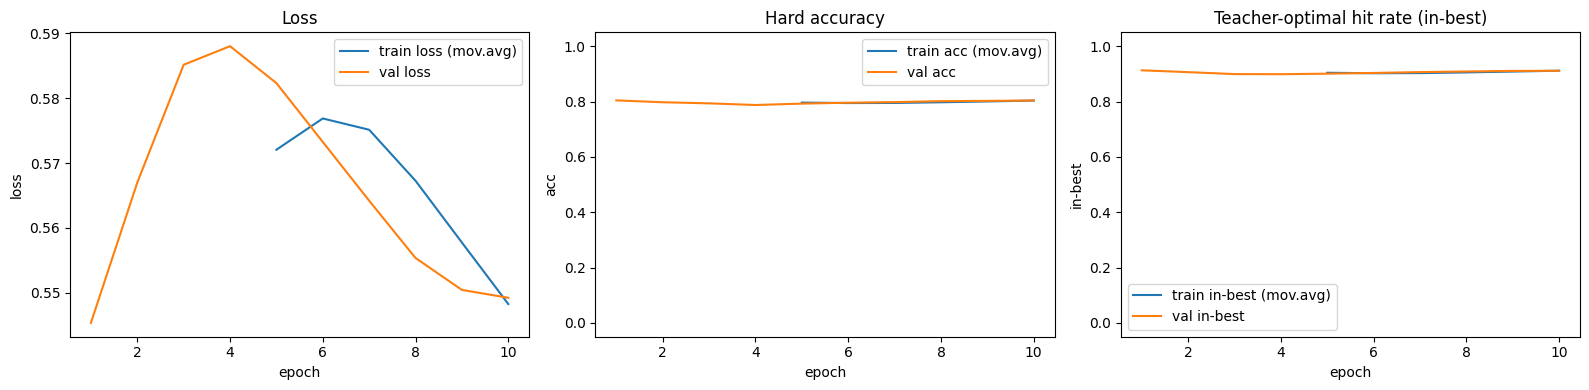

In [10]:
moving = 5

if "epoch" in history and len(history["epoch"]) == len(history["train_loss"]):
    train_x = np.array(history["epoch"], dtype=int)
else:
    train_x = np.arange(1, len(history["train_loss"]) + 1)

val_x = train_x

def moving_average(data, m):
    data = list(data)
    if len(data) < m:
        return data[:]
    return [np.mean(data[i:i+m]) for i in range(len(data) - m + 1)]

avg_tr_loss = moving_average(history["train_loss"], moving)
avg_tr_acc  = moving_average(history["train_acc"], moving)
avg_tr_best = moving_average(history["train_inbest"], moving)

if len(history["train_loss"]) >= moving:
    avg_x = train_x[moving - 1:]
else:
    avg_x = train_x

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(16, 4))

# Loss
ax0.plot(avg_x, avg_tr_loss, label="train loss (mov.avg)")
ax0.plot(val_x, history["val_loss"], label="val loss")
ax0.set_title("Loss")
ax0.set_xlabel("epoch")
ax0.set_ylabel("loss")
ax0.legend()

# Hard accuracy
ax1.plot(avg_x, avg_tr_acc, label="train acc (mov.avg)")
ax1.plot(val_x, history["val_acc"], label="val acc")
ax1.set_title("Hard accuracy")
ax1.set_xlabel("epoch")
ax1.set_ylabel("acc")
ax1.set_ylim(-0.05, 1.05)
ax1.legend()

# In-best accuracy
ax2.plot(avg_x, avg_tr_best, label="train in-best (mov.avg)")
ax2.plot(val_x, history["val_inbest"], label="val in-best")
ax2.set_title("Teacher-optimal hit rate (in-best)")
ax2.set_xlabel("epoch")
ax2.set_ylabel("in-best")
ax2.set_ylim(-0.05, 1.05)
ax2.legend()

plt.tight_layout()
plt.show()


In [11]:
# Quick sanity check (predict a few samples)
@torch.no_grad()
def show_predictions(n_show=8):
    model.eval()
    xs, ys, ps = next(iter(dl_val))
    xs = xs[:n_show].to(DEVICE)
    ys = ys[:n_show].numpy()

    logits, _ = model(xs)
    pred = logits.argmax(dim=1).cpu().numpy()

    out = pd.DataFrame({"y_action": ys, "pred": pred})
    return out

show_predictions(16)


,y_action,pred
0,4,3
1,1,1
2,3,2
3,4,4
4,5,5
5,2,2
6,4,5
7,3,3
8,2,2
9,4,4


,n,acc,top2_acc
0,598730,0.804085,0.932636


,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6
y0,42821,988,1809,1166,1919,903,1386
y1,2186,52885,2182,3075,3150,2673,1333
y2,1608,2557,81478,5949,4153,3616,1403
y3,2011,4355,8689,129537,9082,4559,2017
y4,1790,2927,3791,5726,81844,3386,1300
y5,2079,2757,3293,3036,2453,52188,1678
y6,2894,1288,1958,1038,2012,1125,40677


,in_top2_0,in_top2_1,in_top2_2,in_top2_3,in_top2_4,in_top2_5,in_top2_6
y0,48280,5510,13869,6149,11687,5001,11488
y1,11459,62876,12090,13364,14911,11916,8352
y2,12723,15372,93902,23006,24318,21233,10974
y3,15513,22280,53861,149809,45079,21153,12805
y4,10695,15587,24248,21851,93113,25821,10213
y5,10034,8673,19049,12094,12850,62688,9580
y6,9058,7604,10730,5870,8575,12418,47729


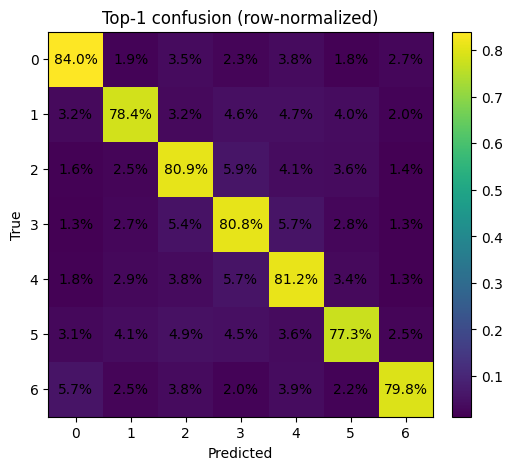

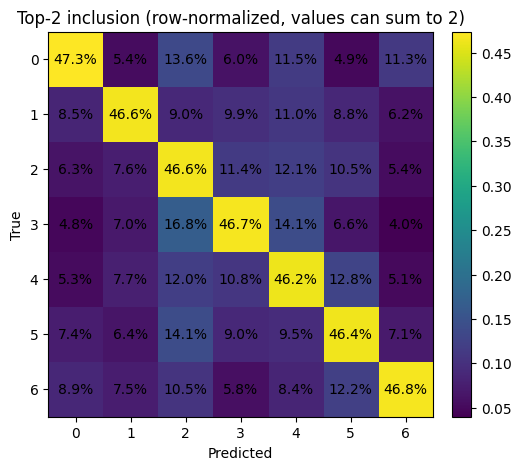

In [12]:
# Confusion matrices for top-1 accuracy and top-2 accuracy (vs hard labels y_action)
@torch.no_grad()
def eval_confusions(dl, device, k=2):
    model.eval()

    # infer number of classes from first batch
    x0, y0, _ = next(iter(dl))
    x0 = x0.to(device)
    logits0, _ = model(x0[:1])
    C = int(logits0.shape[1])

    cm_top1 = torch.zeros((C, C), dtype=torch.int64)   # rows=true, cols=pred(top1)
    cm_topk = torch.zeros((C, C), dtype=torch.int64)   # rows=true, cols=member of top-k

    total = 0
    correct1 = 0
    correctk = 0

    for x, y_action, _ in dl:
        x = x.to(device, non_blocking=True)
        y = y_action.to(device, non_blocking=True).long()

        logits, _ = model(x)

        pred1 = logits.argmax(dim=1)
        topk = logits.topk(k=min(k, C), dim=1).indices  # (B,k)

        total += y.numel()
        correct1 += (pred1 == y).sum().item()
        correctk += (topk == y.unsqueeze(1)).any(dim=1).sum().item()

        # --- top-1 confusion ---
        y_cpu = y.detach().cpu()
        p_cpu = pred1.detach().cpu()
        idx = y_cpu * C + p_cpu
        cm_top1 += torch.bincount(idx, minlength=C*C).view(C, C)

        # --- top-k "inclusion" matrix ---
        # For each sample, increment (true=y, col=j) for every j in the model's top-k set
        y_rep = y_cpu.unsqueeze(1).expand(-1, topk.size(1)).reshape(-1)
        topk_flat = topk.detach().cpu().reshape(-1)
        idxk = y_rep * C + topk_flat
        cm_topk += torch.bincount(idxk, minlength=C*C).view(C, C)

    metrics = {
        "n": total,
        "acc": correct1 / total,
        "top2_acc": correctk / total if k == 2 else correctk / total,
    }
    return metrics, cm_top1, cm_topk

def cm_to_df(cm, prefix="c"):
    C = cm.shape[0]
    cols = [f"{prefix}{i}" for i in range(C)]
    rows = [f"y{i}" for i in range(C)]
    return pd.DataFrame(cm.numpy(), index=rows, columns=cols)

def plot_cm(cm, title, normalize="true", annotate=True, pct_decimals=1):
    """normalize: None | 'true' (row) | 'pred' (col) | 'all'"""
    mat = cm.to(torch.float32)

    # normalize for plotting
    if normalize == "true":
        denom = mat.sum(dim=1, keepdim=True).clamp_min(1)
        mat = mat / denom
    elif normalize == "pred":
        denom = mat.sum(dim=0, keepdim=True).clamp_min(1)
        mat = mat / denom
    elif normalize == "all":
        mat = mat / mat.sum().clamp_min(1)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat.numpy())
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_xticks(range(mat.shape[1]))
    ax.set_yticks(range(mat.shape[0]))

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # annotate with percentages (only meaningful when normalized)
    if annotate and normalize is not None:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = float(mat[i, j].item())
                ax.text(j, i, f"{v*100:.{pct_decimals}f}%", ha="center", va="center")

    plt.show()


# Run on validation loader
metrics, cm_top1, cm_top2_incl = eval_confusions(dl_val, DEVICE, k=2)
display(pd.DataFrame([metrics]))

# Confusion matrix for top-1 predictions (standard)
display(cm_to_df(cm_top1, prefix="pred_"))

# "Top-2 inclusion matrix":
# row=y, col=j counts how often j appears in the model's top-2 set when the true label is y.
# (Each row sums to ~ 2 * count(y), unless k is clipped by C.)
display(cm_to_df(cm_top2_incl, prefix="in_top2_"))

# Plots (row-normalized)
plot_cm(cm_top1, "Top-1 confusion (row-normalized)", normalize="true")
plot_cm(cm_top2_incl, "Top-2 inclusion (row-normalized, values can sum to 2)", normalize="true")